# 01 — Análise Exploratória de Dados (EDA)

**Objetivo:** Entender a estrutura, qualidade e distribuição dos dados antes de qualquer transformação.

**Inputs:** `data/raw/dataset.csv`

**Outputs:** `reports/figures/*.png`

---

**Roteiro:**

1. Setup — imports e carregamento
2. Inspeção inicial — shape, tipos, nulos, describe
3. Distribuição do Target
4. Distribuições Univariadas — Numéricas
5. Análise Bivariada — Numéricas vs Attrition + Mann-Whitney U
6. Análise Bivariada — Categóricas vs Attritio
7. Correlação
8. Síntese — Hipóteses para o NB02


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu


from src.config import CAMINHOS, CONFIG
from src.viz_config import CORES, PALETTE


SEED = CONFIG["dados"]["random_state"]
TARGET = CONFIG["dados"]["target_col"]

DATA_DIR = CAMINHOS.dados_raw
FIG_DIR = CAMINHOS.figures
FIG_DIR.mkdir(parents=True, exist_ok=True)


print("✅ Setup OK")
print(f"   TARGET   : {TARGET}")
print(f"   DATA_DIR : {DATA_DIR}")
print(f"   FIG_DIR  : {FIG_DIR}")

✅ Setup OK
   TARGET   : Attrition
   DATA_DIR : C:\Users\jas_t\Repo\Portfolios\ibm_attrition\data\raw
   FIG_DIR  : C:\Users\jas_t\Repo\Portfolios\ibm_attrition\reports\figures


### Etapa 2 - Carregamento e Inspeção Inicial

In [2]:
df = pd.read_csv(DATA_DIR / CAMINHOS.dados_brutos)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
with pd.option_context("display.max_columns", None):
    display(df.describe().round(2))

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


- As variáveis do tipo Likert (1–4) — `EnvironmentSatisfaction`, `JobSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance` e `JobInvolvement` — possuem média próxima de 2.7. Apesar de armazenadas como numéricas, representam escalas ordinais e exigem interpretação adequada durante a análise.
- A feature PerformanceRating apresenta baixa variabilidade:
    - aproximadamente 75% dos funcionários possuem nota 3;
    - valor máximo igual a 4.
- A variável MonthlyIncome apresenta distribuição altamente assimétrica:
    - mediana: 4919
    - média: 6502
    - valor máximo: 19999
    - indica presença significativa de outliers.

In [5]:
df.describe(exclude="number")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [6]:
print(f'Shape  : {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Nulos  : {df.isnull().sum().sum()}')
print(f'Duplic.: {df.duplicated().sum()}')

Shape  : 1470 linhas × 35 colunas
Nulos  : 0
Duplic.: 0


In [7]:
constantes = [c for c in df.columns if df[c].nunique() <= 1]
print(f"Colunas constantes (descartar): {constantes}")

Colunas constantes (descartar): ['EmployeeCount', 'Over18', 'StandardHours']


- O dataset já se encontra totalmente tratado, sem valores nulos e sem registros duplicados.
 
- Algumas variáveis foram identificadas como irrelevantes para modelagem e removidas:
    - `EmployeeCount` e `StandardHours`: variáveis constantes, sem variabilidade estatística;
    - `Over18`: possui apenas o valor "Y" para todos os registros;
    - `EmployeeNumber`: identificador único, sem capacidade preditiva.

### Etapa 3 - Distribuição do Target

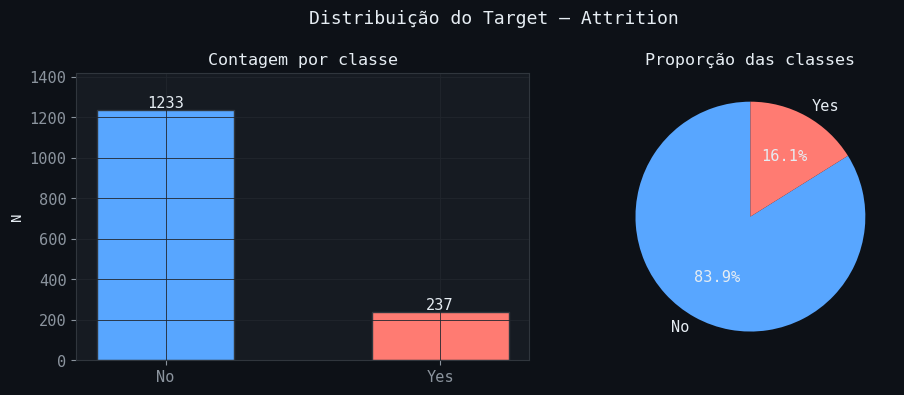

Classe majoritária (No) : 83.9%
Classe minoritária (Yes): 16.1%
Razão de desbalanceamento: 5.2:1


In [8]:
counts = df[TARGET].value_counts()
pct    = df[TARGET].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── BoxPlot ─────────────────────────────────
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE[0], PALETTE[1]], edgecolor='#30363d', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 15,
                 str(val), ha='center', color='#e6edf3', fontsize=11)
axes[0].set_title('Contagem por classe', color='#e6edf3')
axes[0].set_ylabel('N')
axes[0].set_ylim(0, counts.max() * 1.15)

# ── Gráfico de torta ─────────────────────────
axes[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
            colors=[PALETTE[0], PALETTE[1]], startangle=90,
            textprops={'color': '#e6edf3'})
axes[1].set_title('Proporção das classes', color='#e6edf3')

plt.suptitle('Distribuição do Target — Attrition', color='#e6edf3', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_01_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Classe majoritária (No) : {pct["No"]:.1f}%')
print(f'Classe minoritária (Yes): {pct["Yes"]:.1f}%')
print(f'Razão de desbalanceamento: {counts["No"] / counts["Yes"]:.1f}:1')

A variável target apresenta forte desbalanceamento:

- `No`: 1233 registros (~84%)
- `Yes`: 237 registros (~16%)

Esse cenário indica a necessidade de técnicas de balanceamento nas etapas de modelagem, como `class_weight` ou `SMOTE` e avaliar por ROC-AUC e Recall, não por accuracy.

### Etapa 4 - Distribuições Univariadas — Numéricas

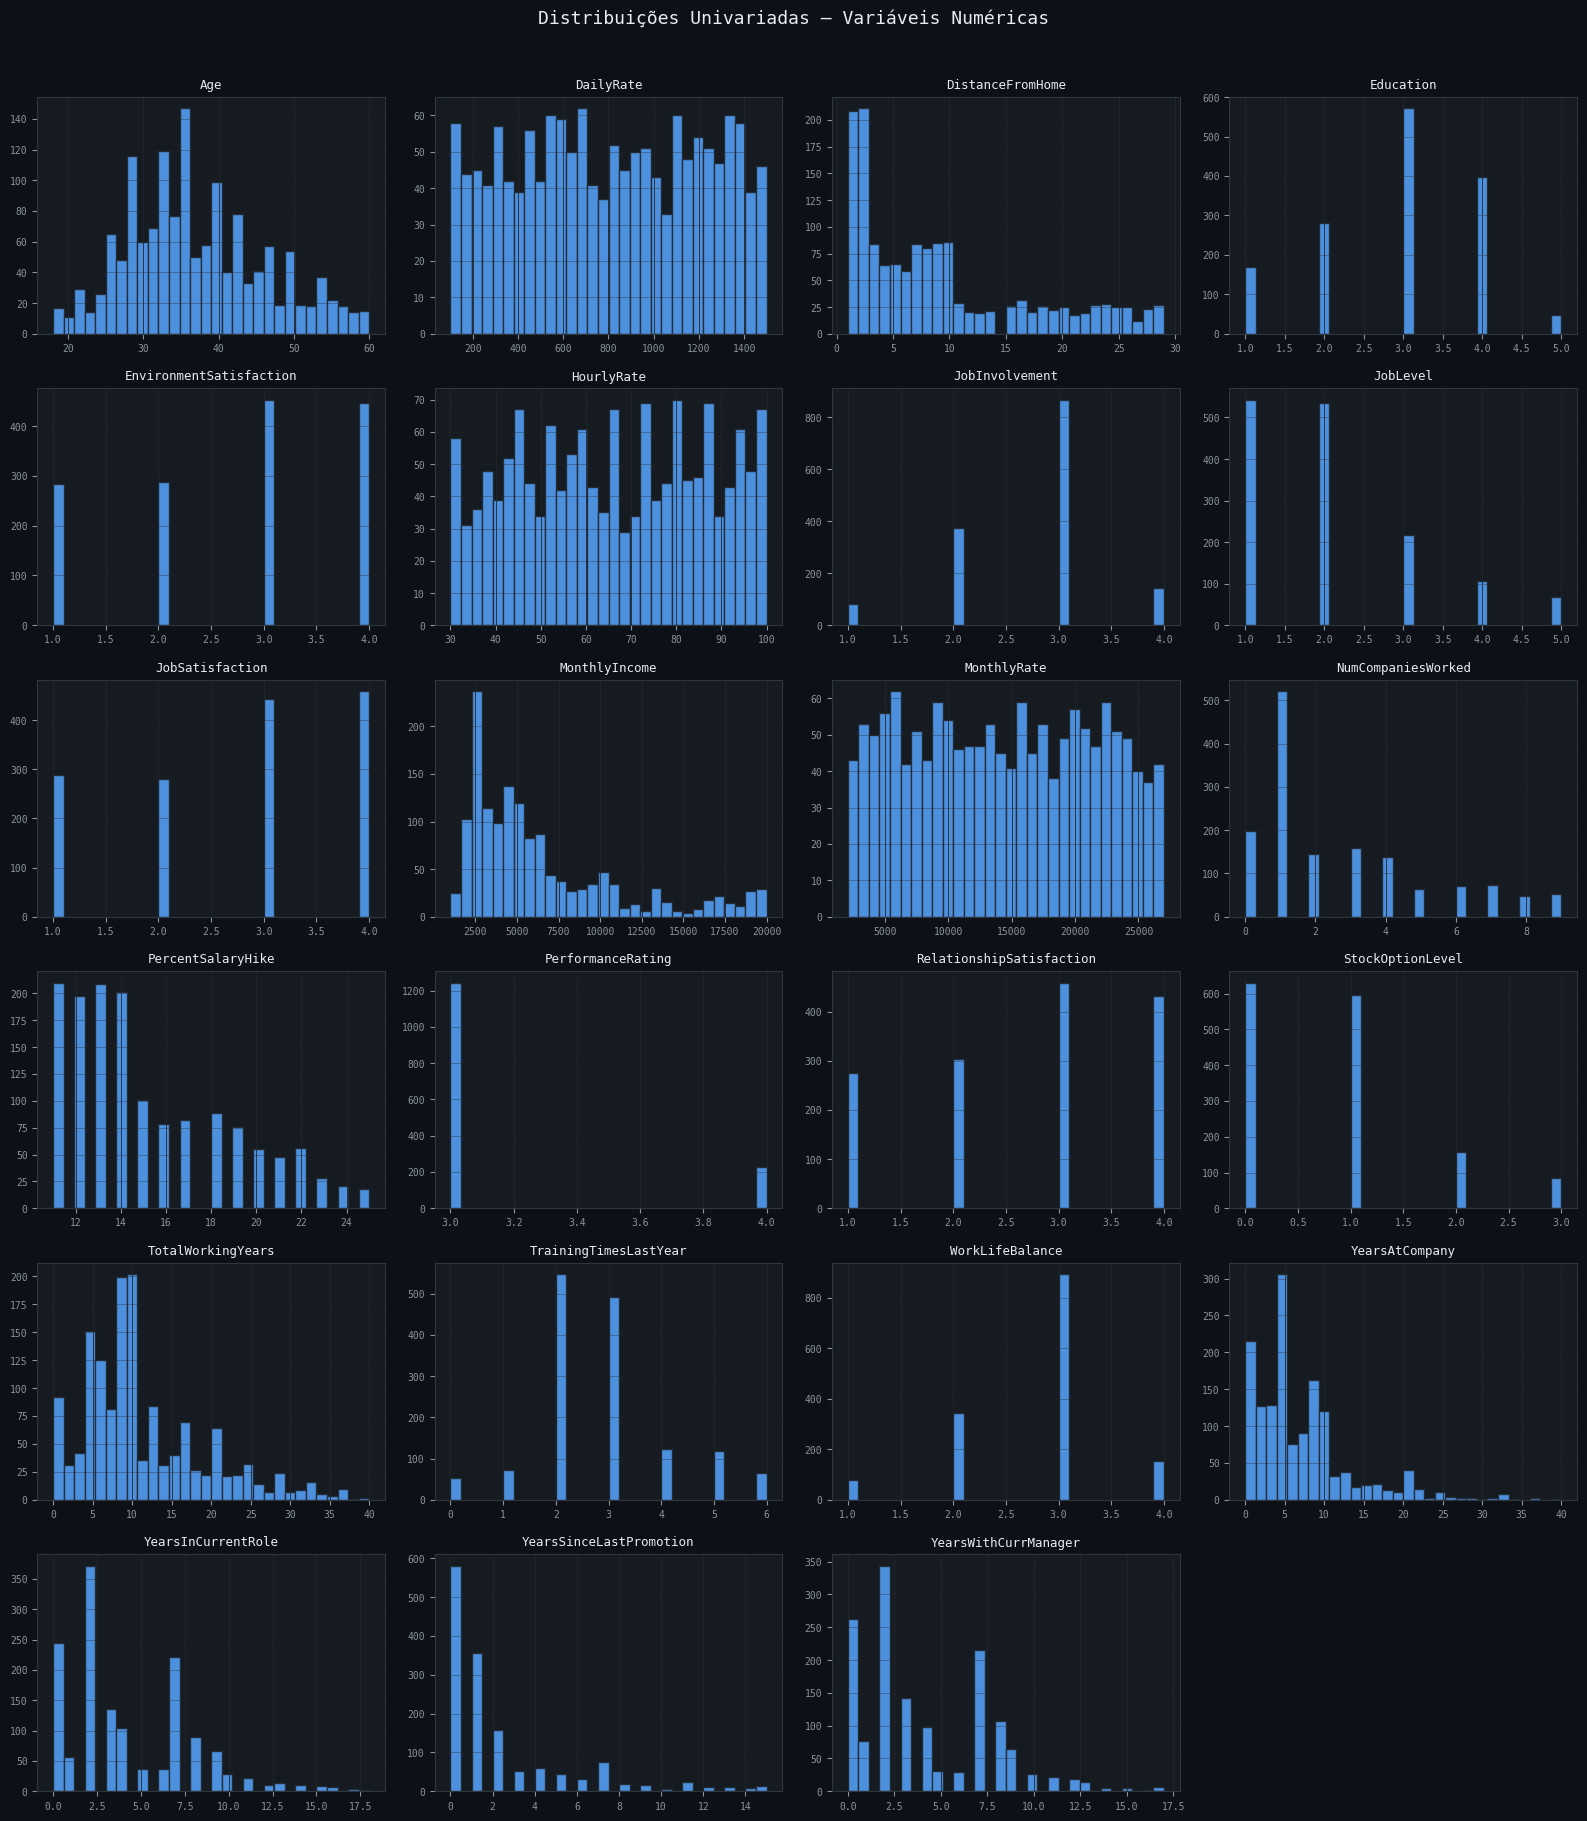

Total de features numéricas analisadas: 23


In [9]:
COLS_DROP_NUM = ['EmployeeCount', 'StandardHours', 'EmployeeNumber']
numericas = (df.select_dtypes(include='number').drop(columns=COLS_DROP_NUM))

n_cols = 4
n_rows = int(np.ceil(len(numericas.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numericas.columns):
    axes[i].hist(numericas[col], bins=30,
                 color=PALETTE[0], edgecolor='#21262d', alpha=0.85)
    axes[i].set_title(col, color='#e6edf3', fontsize=9)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(axis='y', alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuições Univariadas — Variáveis Numéricas',
             color='#e6edf3', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_02_distribuicoes_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total de features numéricas analisadas: {len(numericas.columns)}')

- As variáveis `Age`, `DailyRate`, `HourlyRate` e `MonthlyRate` apresentam distribuições aproximadamente simétricas, com comportamento próximo ao normal e sem padrões anômalos relevantes.
- Algumas features exibem forte assimetria à direita, indicando concentração da maior parte dos funcionários em valores baixos e presença de caudas longas.
- A feature PerformanceRating possui baixíssima variabilidade:
    - predominância quase absoluta do valor 3;
    - poucos registros com valor 4.

Esse padrão sugere baixo poder informacional, tornando a variável uma possível candidata a remoção nas etapas posteriores de feature selection.

- A variável `StockOptionLevel` apresenta distribuição fortemente concentrada nos níveis `0` e `1`, com baixa frequência nos níveis `2` e `3`, caracterizando uma distribuição bastante assimétrica.

### Etapa 5 - Análise Bivariada — Numéricas vs Attrition + Mann-Whitney U

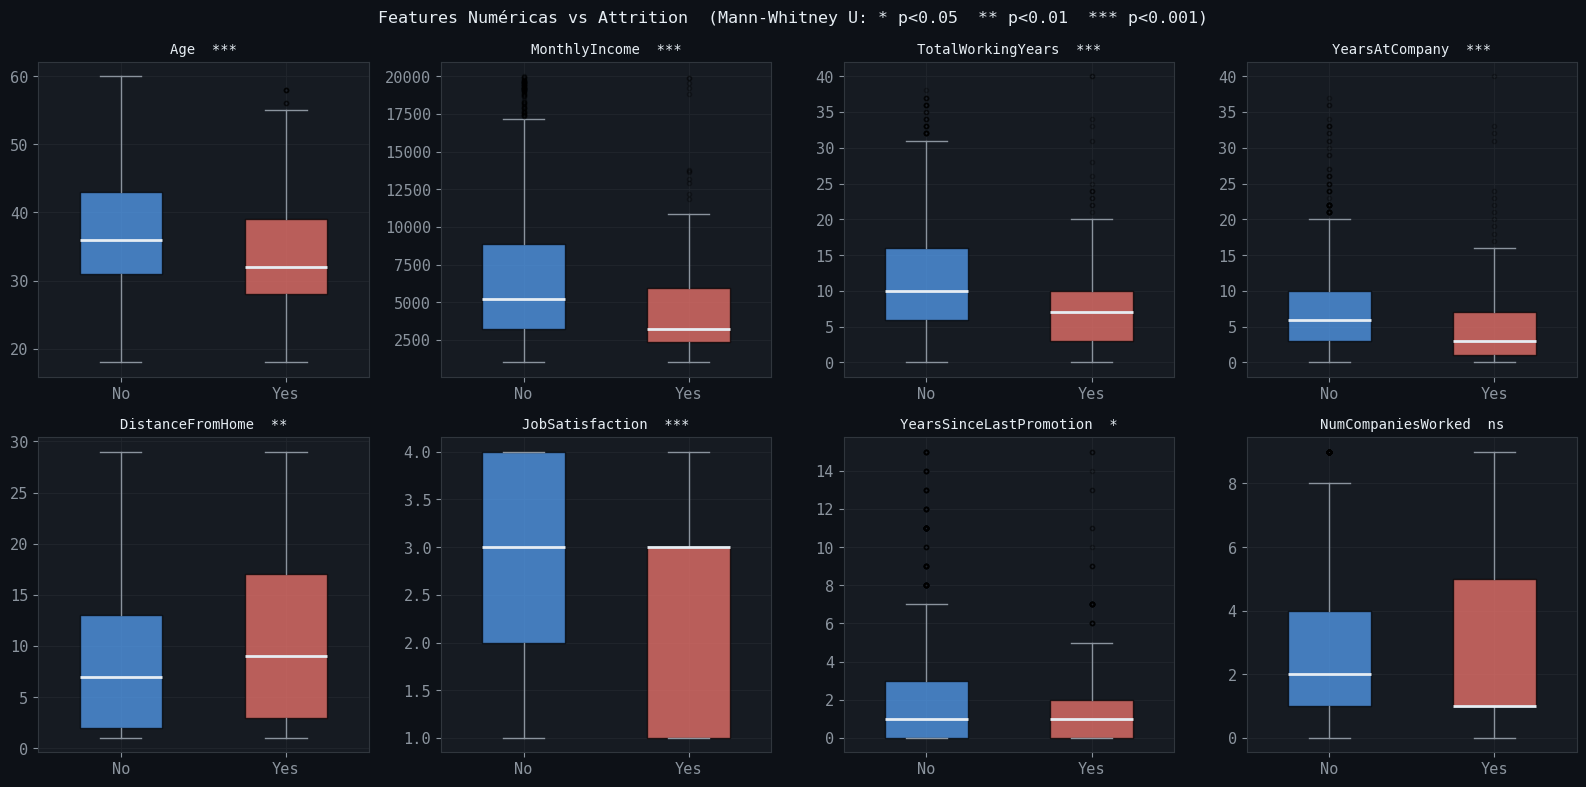


=== Mann-Whitney U — Diferença entre grupos No vs Yes ===


,Feature,U-stat,p-value,Sig.
0,Age,185362.0,0.0000,***
1,MonthlyIncome,191600.5,0.0000,***
2,TotalWorkingYears,191654.0,0.0000,***
3,YearsAtCompany,189639.0,0.0000,***
5,JobSatisfaction,168858.5,0.0001,***
4,DistanceFromHome,127995.5,0.0024,**
6,YearsSinceLastPromotion,157847.0,0.0412,*
7,NumCompaniesWorked,139291.5,0.2424,ns


In [10]:
FEATURES_FOCO = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears',
    'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction',
    'YearsSinceLastPromotion', 'NumCompaniesWorked'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

resultados_mw = []

for i, col in enumerate(FEATURES_FOCO):
    grupo_no  = df.loc[df[TARGET] == 'No',  col]
    grupo_yes = df.loc[df[TARGET] == 'Yes', col]

    # ── Teste Mann-Whitney U ─────────────────────────
    stat, p = mannwhitneyu(grupo_no, grupo_yes, alternative='two-sided')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    resultados_mw.append({'Feature': col, 'U-stat': round(stat, 1), 'p-value': round(p, 4), 'Sig.': sig})

    # ── BoxPlot ─────────────────────────
    for j, (grupo, dados, cor) in enumerate(zip(
        ['No', 'Yes'], [grupo_no, grupo_yes], [PALETTE[0], PALETTE[1]]
    )):
        axes[i].boxplot(
            dados, positions=[j], widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor=cor, alpha=0.7),
            medianprops=dict(color='#e6edf3', linewidth=2),
            whiskerprops=dict(color='#8b949e'),
            capprops=dict(color='#8b949e'),
            flierprops=dict(marker='o', color=cor, alpha=0.3, markersize=3)
        )

    axes[i].set_title(f'{col}  {sig}', color='#e6edf3', fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No', 'Yes'])

plt.suptitle('Features Numéricas vs Attrition  (Mann-Whitney U: * p<0.05  ** p<0.01  *** p<0.001)',
             color='#e6edf3', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_03_bivar_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela de resultad ─────────────────────────
df_mw = pd.DataFrame(resultados_mw).sort_values('p-value')
print('\n=== Mann-Whitney U — Diferença entre grupos No vs Yes ===')
display(df_mw)

- As variáveis com maior significância estatística (p < 0.001) foram: `Age` ,`MonthlyIncome` ,`TotalWorkingYears`, `YearsAtCompany`, `JobSatisfaction`.
- Os resultados indicam que funcionários que deixam a empresa tendem a:
    - ser mais jovens;
    - possuir menor renda;
    - ter menos experiência profissional;
    - apresentar menor tempo de permanência na empresa;
    - demonstrar menor satisfação no trabalho.

Essas features se destacam como os preditores mais promissores para os modelos de classificação de churn/attrition.

### Etapa 6 - Análise Bivariada — Categóricas vs Attritio

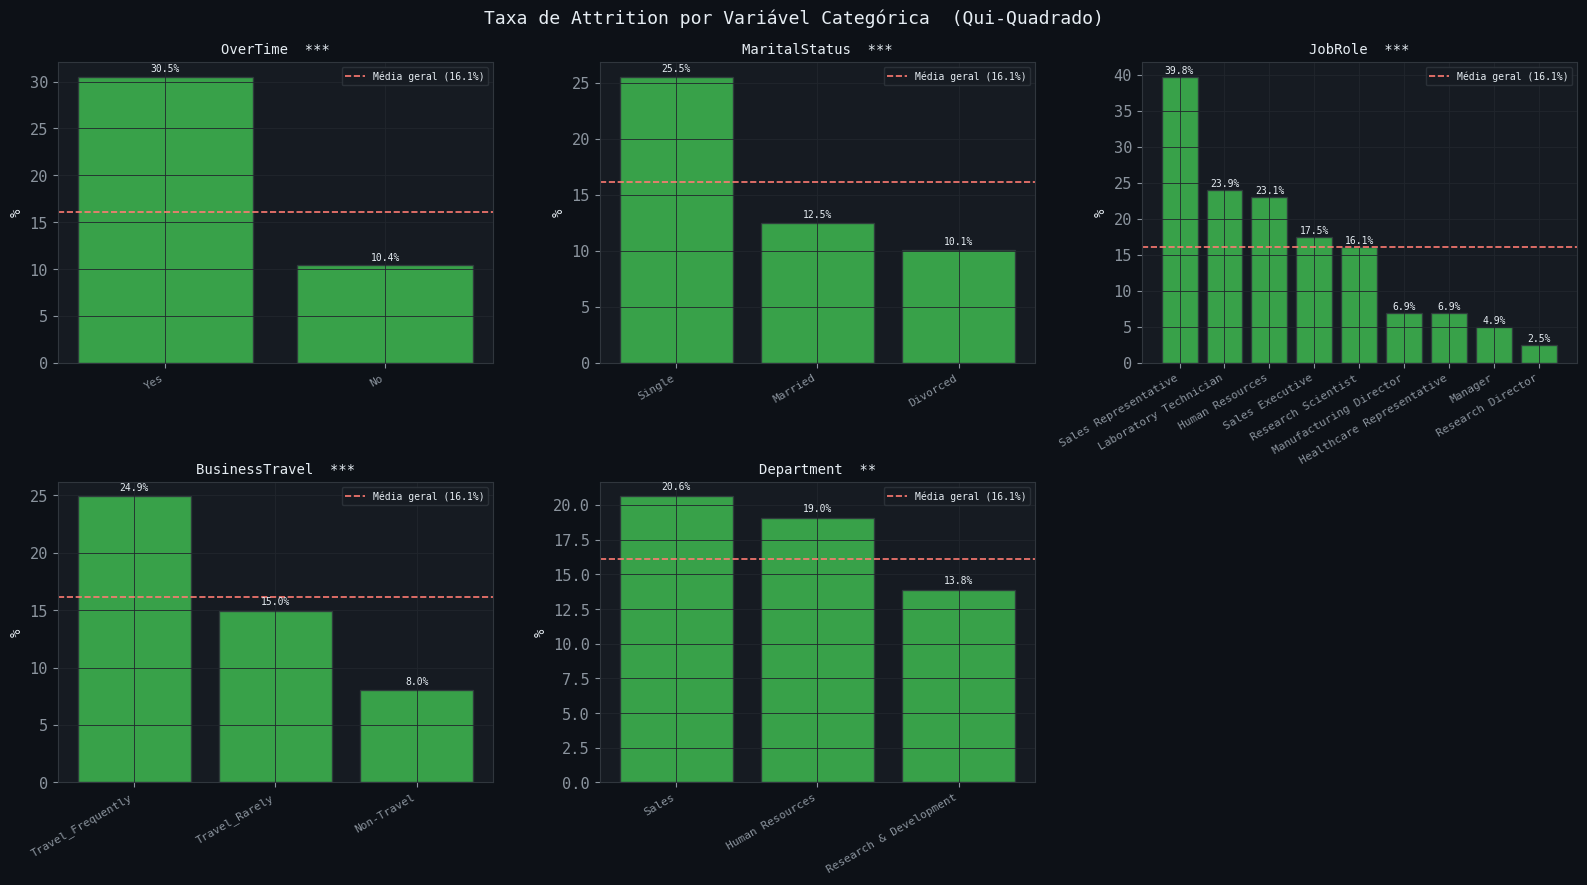


=== Qui-Quadrado — Associação com Attrition ===


,Feature,chi2,p-value,Sig.
0,OverTime,87.56,0.0000,***
1,MaritalStatus,46.16,0.0000,***
2,JobRole,86.19,0.0000,***
3,BusinessTravel,24.18,0.0000,***
4,Department,10.80,0.0045,**


In [11]:
CATS = ['OverTime', 'MaritalStatus', 'JobRole', 'BusinessTravel', 'Department']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

resultados_chi2 = []
media_geral = (df[TARGET] == 'Yes').mean() * 100

for i, col in enumerate(CATS):
    
    taxa = (df.groupby(col)[TARGET].apply(lambda x: (x == 'Yes').mean() * 100)
              .sort_values(ascending=False))

    tabela = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = chi2_contingency(tabela)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    resultados_chi2.append({'Feature': col, 'chi2': round(chi2, 2), 'p-value': round(p, 4), 'Sig.': sig})

    # ── Plot ──────────────────────────────
    bars = axes[i].bar(range(len(taxa)), taxa.values,
                       color=PALETTE[2], edgecolor='#30363d', alpha=0.85)
    axes[i].axhline(y=media_geral, color=PALETTE[1],
                    linestyle='--', linewidth=1.2, label=f'Média geral ({media_geral:.1f}%)')
    axes[i].set_title(f'{col}  {sig}', color='#e6edf3', fontsize=10)
    axes[i].set_ylabel('%')
    axes[i].set_xticks(range(len(taxa)))
    axes[i].set_xticklabels(taxa.index, rotation=30, ha='right', fontsize=8)
    axes[i].legend(fontsize=7)

    for bar, val in zip(bars, taxa.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=7, color='#e6edf3')

axes[-1].set_visible(False)
plt.suptitle('Taxa de Attrition por Variável Categórica  (Qui-Quadrado)',
             color='#e6edf3', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_04_bivar_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


df_chi2 = pd.DataFrame(resultados_chi2).sort_values('p-value')
print('\n=== Qui-Quadrado — Associação com Attrition ===')
display(df_chi2)

- `OverTime` apresentou o sinal categórico mais forte de todo o dataset:
    - funcionários que realizam horas extras possuem taxa de attrition de 30.5%; entre aqueles que não fazem hora extra, a taxa cai para 10.4%.

- O teste qui-quadrado registrou `χ² = 87.56`, o maior valor observado, evidenciando uma associação extremamente forte entre excesso de trabalho e saída da empresa.

- O cargo `Sales Representative` se destacou como a função de maior risco:
    - taxa de attrition de 39.8%, mais que o dobro da média geral do dataset (16.1%).

O resultado sugere alta pressão, rotatividade ou desgaste específico dessa função.

- O estado civil também apresentou impacto relevante:
    - funcionários solteiros possuem attrition de 25.5%; divorciados apresentam apenas 10.1%.

Esse comportamento pode estar relacionado a maior mobilidade profissional e menor vínculo local entre funcionários solteiros.

- A variável `BusinessTravel` demonstrou efeito significativo:
    - funcionários que viajam frequentemente apresentam attrition de 24.9%; entre aqueles que não viajam, a taxa cai para aproximadamente 8%.

    O resultado sugere influência direta do desgaste associado a viagens constantes.

- A variável `Department` apresentou a associação mais fraca entre as categóricas analisadas:
    - `p = 0.004` e `χ² = 10.80`

Embora estatisticamente significativa, a magnitude do efeito é menor, indicando que o impacto do departamento provavelmente é mediado pelo cargo exercido.

### Etapa 7 - Correlação

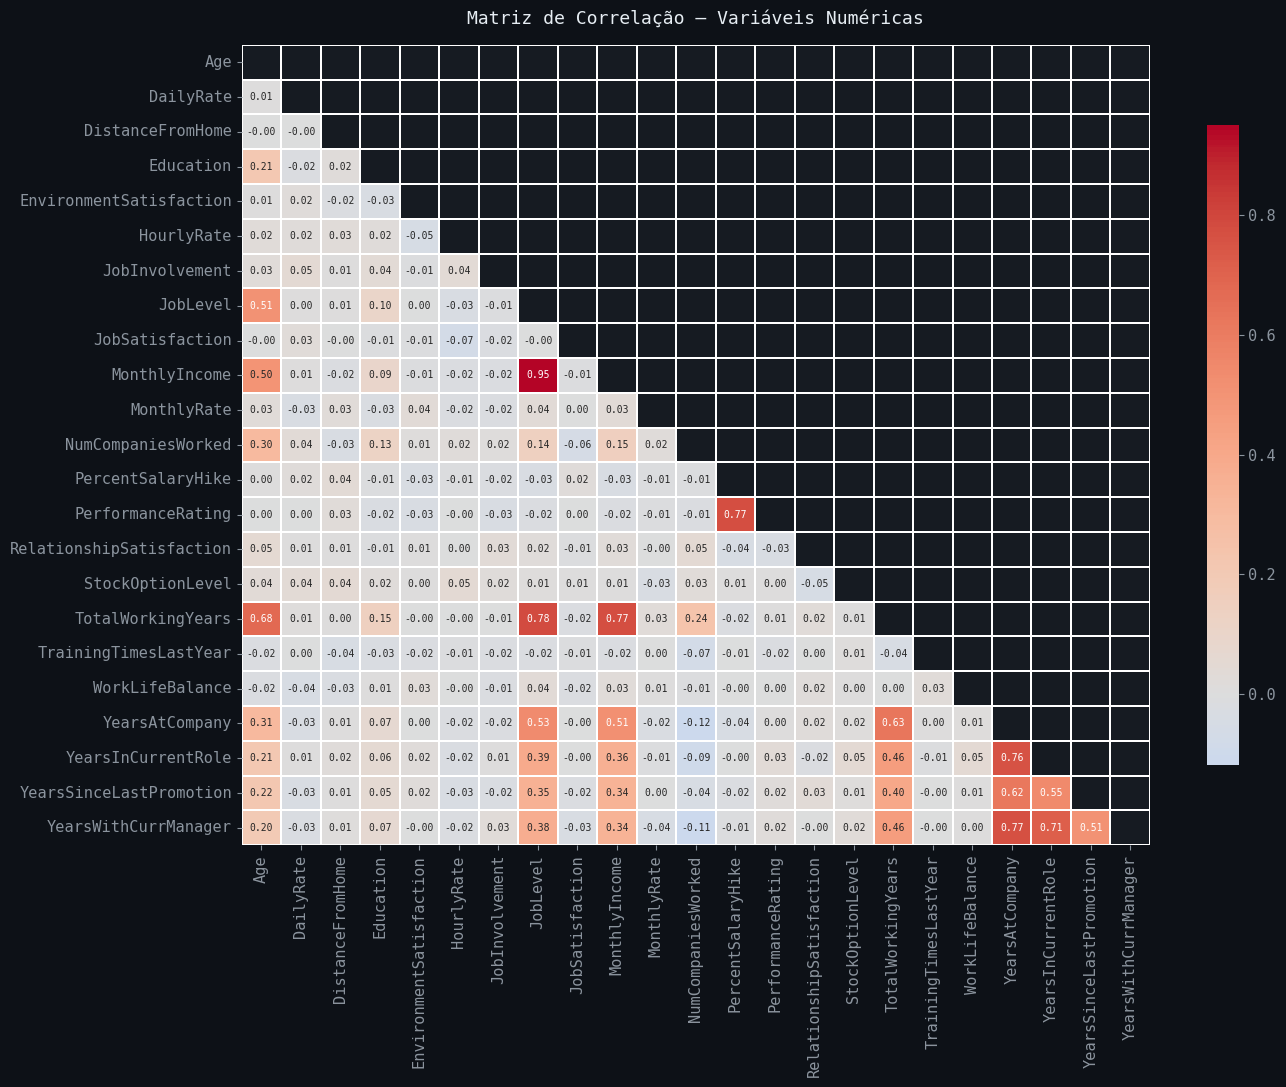

=== Pares com |correlação| > 0.7 ===


,Feature A,Feature B,r
214,MonthlyIncome,JobLevel,0.950
375,TotalWorkingYears,JobLevel,0.782
311,PerformanceRating,PercentSalaryHike,0.774
377,TotalWorkingYears,MonthlyIncome,0.773
525,YearsWithCurrManager,YearsAtCompany,0.769
479,YearsInCurrentRole,YearsAtCompany,0.759
526,YearsWithCurrManager,YearsInCurrentRole,0.714


In [12]:
corr = numericas.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.3,
    ax=ax, annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação — Variáveis Numéricas',
             color='#e6edf3', fontsize=13, pad=15)
plt.tight_layout()
plt.grid(False)
plt.savefig(FIG_DIR / 'eda_05_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Pares com correlação alta (|r| > 0.7) ──────────────────────────────
print('=== Pares com |correlação| > 0.7 ===')
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                  .stack()
                  .reset_index())
corr_pairs.columns = ['Feature A', 'Feature B', 'r']
corr_pairs = corr_pairs[corr_pairs['r'].abs() > 0.7].sort_values('r', ascending=False)
display(corr_pairs.round(3))

* A correlação entre `MonthlyIncome` e `JobLevel` foi extremamente elevada (`r = 0.95`), indicando que ambas carregam praticamente a mesma informação preditiva:

  * Funcionários em níveis hierárquicos mais altos tendem a possuir salários proporcionalmente maiores.
  * Para reduzir redundância no modelo, a estratégia considerada é manter apenas `MonthlyIncome` ou utilizar métricas como VIF (*Variance Inflation Factor*) para determinar qual variável apresenta maior valor informacional.

* Foi identificado um cluster relacionado ao tempo de permanência na empresa, envolvendo as variáveis `YearsAtCompany`, `YearsInCurrentRole` e `YearsWithCurrManager`:

  * Essas variáveis apresentaram correlações entre `0.71` e `0.77`, caracterizando um claro caso de multicolinearidade.
  * Os resultados sugerem que funcionários com maior tempo de empresa tendem a permanecer no mesmo cargo e sob a mesma gestão por períodos prolongados.

* A variável `TotalWorkingYears` também apresentou forte associação com `JobLevel` e `MonthlyIncome`:

  * Isso indica que a experiência profissional acumulada está diretamente relacionada tanto ao nível hierárquico quanto à renda do funcionário, formando um conjunto de variáveis altamente correlacionadas.

* A correlação entre `PerformanceRating` e `PercentSalaryHike` também foi elevada:

  * Nesse contexto, manter apenas uma das variáveis pode ser suficiente para evitar redundância e reduzir multicolinearidade no modelo.


### 8. Síntese — Hipóteses para o NB02

#### Decisões de limpeza
- Descartar `EmployeeCount`, `Over18`, `StandardHours` (constantes)
- Descartar `EmployeeNumber` (identificador)
- Descartar `JobLevel` (r=0.95 com `MonthlyIncome`)
- Descartar `PerformanceRating` (r=0.77 com `PercentSalaryHike`, baixa variância)
- Converter `Attrition` para binário: Yes → 1, No → 0

#### Features mais promissoras (preditores fortes)
| Feature | Evidência |
|---|---|
| OverTime | Taxa 30.5% vs 10.4% — chi²=87.56 *** |
| MonthlyIncome | Mediana Yes muito menor — MW *** |
| Age | Funcionários mais jovens saem mais — MW *** |
| TotalWorkingYears | Menos experiência → mais saída — MW *** |
| JobRole (Sales Rep.) | 39.8% de attrition — chi²=86.19 *** |
| MaritalStatus (Single) | 25.5% vs 10.1% — chi²=46.16 *** |
| JobSatisfaction | Satisfação menor no grupo Yes — MW *** |

#### Alertas de multicolinearidade
- `MonthlyIncome` ↔ `JobLevel` (r=0.95) → manter MonthlyIncome
- `TotalWorkingYears` ↔ `MonthlyIncome` (r=0.77) → verificar VIF no NB02
- Cluster: `YearsAtCompany` / `YearsInCurrentRole` / `YearsWithCurrManager` → verificar VIF

#### Desbalanceamento
- Razão 5.2:1 → usar `scale_pos_weight` no XGBoost e avaliar por ROC-AUC + Recall

In [13]:
# ── 9. Fechamento ─────────────────────────────────────────────
figuras = list(FIG_DIR.glob('eda_*.png'))
print('✅ NB01 — EDA finalizado.')
print(f'   Figuras geradas: {len(figuras)}')
for f in sorted(figuras):
    print(f'   → {f.name}')

✅ NB01 — EDA finalizado.
   Figuras geradas: 5
   → eda_01_target.png
   → eda_02_distribuicoes_numericas.png
   → eda_03_bivar_numericas.png
   → eda_04_bivar_categoricas.png
   → eda_05_correlacao.png


### Resumo do que foi feito no NB01

| Etapa | Entregável |
|---|---|
| 1 | Setup — CONFIG, CAMINHOS, estilo GitHub Dark |
| 2 | Inspeção — shape, tipos, nulos, constantes, describe |
| 3 | Distribuição do target — 83.9% No / 16.1% Yes, razão 5.2:1 |
| 4 | Histogramas — 23 features numéricas |
| 5 | Boxplots + Mann-Whitney U — 5 features *** significativas |
| 6 | Taxa de attrition + Qui-Quadrado — OverTime e JobRole como top preditores |
| 7 | Matriz de correlação — 7 pares com r > 0.7 identificados |
| 8 | Síntese Markdown — hipóteses e decisões documentadas para NB02 |